# Solution - trees chapter project (wine quality)

Instructor solution for `trees_project.ipynb`. One classifier built three ways on the same
wine-quality split, with a running scoreboard: single tree (HW1) -> random forest (HW2) ->
gradient boosting (HW3), plus the **importance trap** and **decision-boundary** extensions.

Run top to bottom with the `ma` kernel. Numbers use `random_state = 509`.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, log_loss

SEED = 509

df = pd.read_csv('data/wine.csv')
y = (df['quality'] >= 7).astype(int)          # 'good' wine = quality 7 or above
X = df.drop(columns=['quality'])              # 12 numeric features (11 chemistry + is_red)
feature_names = list(X.columns)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y)
print(X_tr.shape, X_te.shape,
      '| good(>=7) rate:', round(float(y.mean()), 3),
      '| majority-baseline acc:', round(float(1 - y.mean()), 3))

scores = {}   # name -> {'acc':..., 'f1':..., 'auc':...}

def record(name, model):
    # fit on train, score on test, add a row to the running scoreboard
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    scores[name] = dict(acc=accuracy_score(y_te, pred),
                        f1=f1_score(y_te, pred),
                        auc=roc_auc_score(y_te, proba))
    print(f"{name:22s} acc={scores[name]['acc']:.3f}  "
          f"f1={scores[name]['f1']:.3f}  auc={scores[name]['auc']:.3f}")
    return model

(4872, 12) (1625, 12) | good(>=7) rate: 0.197 | majority-baseline acc: 0.803


## HW1 - grow, prune, read a tree ([17])

**1. By hand (Play Tennis).** Information gain of the Outlook stump and of one other split
(Humidity), from the classic 14-row table. We compute it here to check the paper answer.

In [2]:
tennis = pd.DataFrame({
 'Outlook':  ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast',
              'Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
 'Humidity': ['High','High','High','High','Normal','Normal','Normal',
              'High','Normal','Normal','Normal','High','Normal','High'],
 'Wind':     ['Weak','Strong','Weak','Weak','Weak','Strong','Strong',
              'Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
 'Play':     ['No','No','Yes','Yes','Yes','No','Yes',
              'No','Yes','Yes','Yes','Yes','Yes','No']})

def entropy(labels):
    p = labels.value_counts(normalize=True)
    return float(-(p * np.log2(p)).sum())

def info_gain(data, feature, target='Play'):
    H = entropy(data[target])
    n = len(data)
    rem = sum(len(g) / n * entropy(g[target]) for _, g in data.groupby(feature))
    return H - rem

H0 = entropy(tennis['Play'])
print(f"H(S) = {H0:.3f}")
for f in ['Outlook', 'Humidity', 'Wind']:
    print(f"IG({f:8s}) = {info_gain(tennis, f):.3f}")
print("\n-> Outlook wins the root (highest IG), matching the by-hand answer.")

H(S) = 0.940
IG(Outlook ) = 0.247
IG(Humidity) = 0.152
IG(Wind    ) = 0.048

-> Outlook wins the root (highest IG), matching the by-hand answer.


**2. Depth U-curve.** Train vs test ROC-AUC as the tree deepens: train keeps rising to 1.0,
test peaks then sags - the classic overfitting U (here a plateau/sag on AUC).

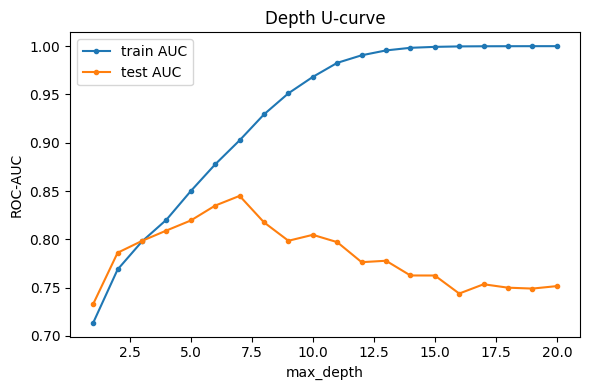

best test AUC at depth 7 = 0.845


In [3]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

depths = range(1, 21)
tr_auc, te_auc = [], []
for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=SEED).fit(X_tr, y_tr)
    tr_auc.append(roc_auc_score(y_tr, t.predict_proba(X_tr)[:, 1]))
    te_auc.append(roc_auc_score(y_te, t.predict_proba(X_te)[:, 1]))

plt.figure(figsize=(6, 4))
plt.plot(list(depths), tr_auc, '-o', ms=3, label='train AUC')
plt.plot(list(depths), te_auc, '-o', ms=3, label='test AUC')
plt.xlabel('max_depth'); plt.ylabel('ROC-AUC'); plt.legend(); plt.title('Depth U-curve')
plt.tight_layout(); plt.show()
print('best test AUC at depth', list(depths)[int(np.argmax(te_auc))],
      '=', round(max(te_auc), 3))

**3. Prune with `ccp_alpha` (chosen by CV), then record and visualize.** We take the
cost-complexity path, pick the alpha with the best 5-fold CV AUC, and `record` the pruned tree.

best ccp_alpha = 0.00081  (CV AUC 0.817)
pruned tree            acc=0.838  f1=0.531  auc=0.836
pruned tree node count: 137


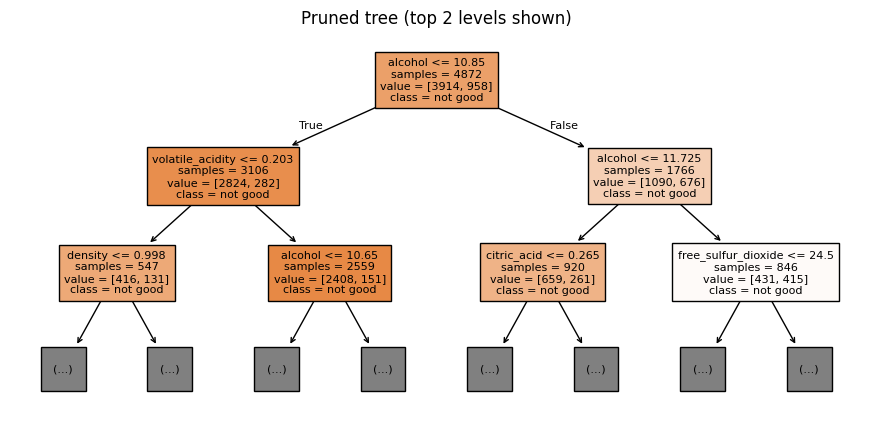

In [4]:
path = DecisionTreeClassifier(random_state=SEED).cost_complexity_pruning_path(X_tr, y_tr)
alphas = path.ccp_alphas[:-1]                    # drop the last (root-only) alpha
alphas = alphas[np.linspace(0, len(alphas) - 1, 25).astype(int)]   # thin to ~25 candidates
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_auc = [cross_val_score(DecisionTreeClassifier(ccp_alpha=a, random_state=SEED),
                          X_tr, y_tr, cv=cv, scoring='roc_auc').mean() for a in alphas]
best_alpha = alphas[int(np.argmax(cv_auc))]
print(f"best ccp_alpha = {best_alpha:.5f}  (CV AUC {max(cv_auc):.3f})")

tree = record('pruned tree', DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=SEED))
print('pruned tree node count:', tree.tree_.node_count)

plt.figure(figsize=(11, 5))
plot_tree(tree, max_depth=2, feature_names=feature_names,
          class_names=['not good', 'good'], filled=True, fontsize=8, impurity=False)
plt.title('Pruned tree (top 2 levels shown)'); plt.show()

**Bonus - scale-invariance and the one-tree LightGBM.** Rescaling a feature leaves a tree's
predictions unchanged (splits are threshold-based). A LightGBM with `n_estimators=1,
learning_rate=1` is *one* tree, but not identical to sklearn's - it bins features first, so
the split points (and AUC) are close, not equal.

In [5]:
# scale-invariance: multiply alcohol by 1000, tree predictions are identical
X_scaled = X_tr.copy(); X_scaled['alcohol'] = X_scaled['alcohol'] * 1000.0
t_a = DecisionTreeClassifier(max_depth=5, random_state=SEED).fit(X_tr, y_tr)
t_b = DecisionTreeClassifier(max_depth=5, random_state=SEED).fit(X_scaled, y_tr)
Xte_scaled = X_te.copy(); Xte_scaled['alcohol'] = Xte_scaled['alcohol'] * 1000.0
same = np.array_equal(t_a.predict(X_te), t_b.predict(Xte_scaled))
print('predictions identical after rescaling alcohol x1000:', same)

# one-tree LightGBM vs one sklearn tree
from lightgbm import LGBMClassifier
lgbm1 = LGBMClassifier(n_estimators=1, learning_rate=1.0, random_state=SEED,
                       verbose=-1).fit(X_tr, y_tr)
skl = DecisionTreeClassifier(random_state=SEED).fit(X_tr, y_tr)
print(f"AUC  LGBM(1 tree)={roc_auc_score(y_te, lgbm1.predict_proba(X_te)[:,1]):.3f}  "
      f"vs sklearn tree={roc_auc_score(y_te, skl.predict_proba(X_te)[:,1]):.3f}  "
      f"(close, not identical - LightGBM bins the features first)")

predictions identical after rescaling alcohol x1000: True


AUC  LGBM(1 tree)=0.818  vs sklearn tree=0.744  (close, not identical - LightGBM bins the features first)


## HW2 - bag the tree ([18])

**1. Random forest: OOB vs 5-fold CV, and onto the scoreboard.** OOB comes free with the fit
and tracks CV closely. The forest should clearly beat the HW1 tree here (unlike Titanic).

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf = record('random forest', RandomForestClassifier(
    n_estimators=300, oob_score=True, random_state=SEED, n_jobs=1))
cv_auc = cross_val_score(
    RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=1),
    X_tr, y_tr, cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring='roc_auc').mean()
print(f"OOB accuracy = {rf.oob_score_:.3f}   |   5-fold CV AUC = {cv_auc:.3f}")

random forest          acc=0.887  f1=0.661  auc=0.922


OOB accuracy = 0.889   |   5-fold CV AUC = 0.907


**2a. `n_estimators` plateau - more trees never overfit, they just converge.**

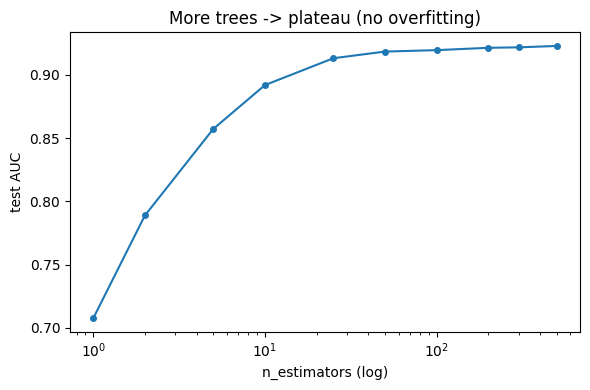

AUC: 1 tree = 0.707 -> 500 trees = 0.923


In [7]:
ns = [1, 2, 5, 10, 25, 50, 100, 200, 300, 500]
te = []
for n in ns:
    m = RandomForestClassifier(n_estimators=n, random_state=SEED, n_jobs=1).fit(X_tr, y_tr)
    te.append(roc_auc_score(y_te, m.predict_proba(X_te)[:, 1]))
plt.figure(figsize=(6, 4))
plt.semilogx(ns, te, '-o', ms=4)
plt.xlabel('n_estimators (log)'); plt.ylabel('test AUC')
plt.title('More trees -> plateau (no overfitting)'); plt.tight_layout(); plt.show()
print('AUC: 1 tree =', round(te[0], 3), '-> 500 trees =', round(te[-1], 3))

**2b. `max_features` matters - the decorrelation knob.**

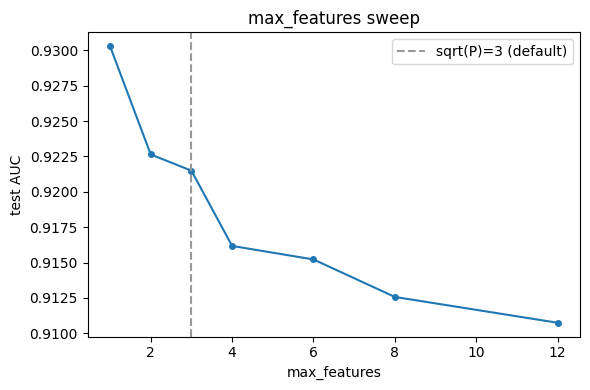

In [8]:
mfs = [1, 2, 3, 4, 6, 8, 12]
te_mf = []
for mf in mfs:
    m = RandomForestClassifier(n_estimators=200, max_features=mf,
                               random_state=SEED, n_jobs=1).fit(X_tr, y_tr)
    te_mf.append(roc_auc_score(y_te, m.predict_proba(X_te)[:, 1]))
plt.figure(figsize=(6, 4))
plt.plot(mfs, te_mf, '-o', ms=4)
plt.axvline(int(np.sqrt(X.shape[1])), color='0.6', ls='--',
            label=f'sqrt(P)={int(np.sqrt(X.shape[1]))} (default)')
plt.xlabel('max_features'); plt.ylabel('test AUC'); plt.legend()
plt.title('max_features sweep'); plt.tight_layout(); plt.show()

### E1 - the importance trap

Add two columns of **pure junk** (Gaussian noise + a random high-cardinality id) and compare
the default **impurity** importance (learned from train) with **permutation** importance
(measured on test). Impurity rewards many split points, so it hands the junk more credit than
the genuine binary `is_red` feature; permutation, judged on held-out data, sends the junk to
the bottom.

                      impurity  imp_rank    perm  perm_rank
alcohol                 0.1448         1  0.0553          1
density                 0.1047         2  0.0306          2
volatile_acidity        0.0775         3  0.0235          3
chlorides               0.0769         4  0.0234          4
sulphates               0.0743         5  0.0198          5
residual_sugar          0.0738         6  0.0164          8
pH                      0.0705         7  0.0130         10
free_sulfur_dioxide     0.0693         8  0.0183          6
total_sulfur_dioxide    0.0687         9  0.0138          9
citric_acid             0.0680        10  0.0172          7
fixed_acidity           0.0578        11  0.0100         11
rand_noise              0.0561        12  0.0020         12
rand_hi_card            0.0545        13  0.0007         13
is_red                  0.0030        14 -0.0001         14


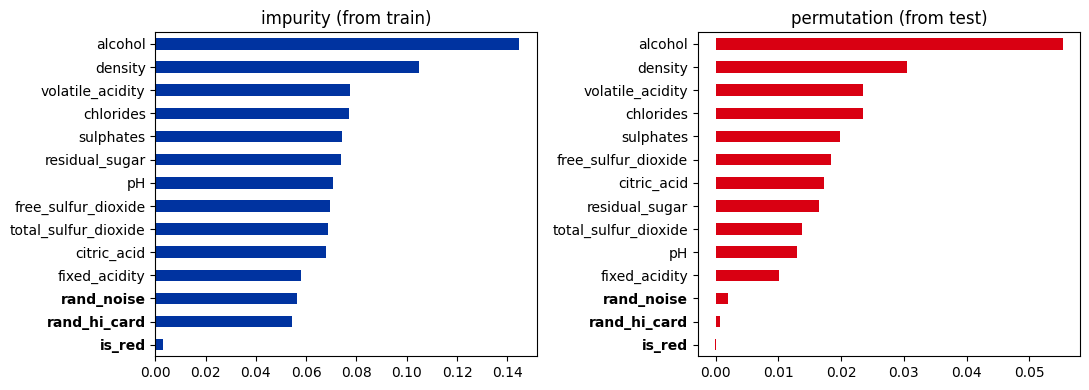


Impurity ranks the two junk columns ABOVE the real 'is_red'; permutation drops them to the bottom. Trust permutation (or SHAP) on held-out data, not the default bar chart.


In [9]:
from sklearn.inspection import permutation_importance
rng = np.random.default_rng(SEED)

X_tr_j, X_te_j = X_tr.copy(), X_te.copy()
X_tr_j['rand_noise']   = rng.normal(size=len(X_tr_j))
X_te_j['rand_noise']   = rng.normal(size=len(X_te_j))
X_tr_j['rand_hi_card'] = rng.integers(0, 4000, len(X_tr_j)).astype(float)
X_te_j['rand_hi_card'] = rng.integers(0, 4000, len(X_te_j)).astype(float)

rf_j = RandomForestClassifier(n_estimators=300, random_state=SEED,
                              n_jobs=1).fit(X_tr_j, y_tr)
imp = pd.Series(rf_j.feature_importances_, index=X_tr_j.columns)
perm = pd.Series(permutation_importance(rf_j, X_te_j, y_te, n_repeats=10,
                                        random_state=SEED, n_jobs=1).importances_mean,
                 index=X_tr_j.columns)
tbl = pd.DataFrame({'impurity': imp, 'imp_rank': imp.rank(ascending=False).astype(int),
                    'perm': perm, 'perm_rank': perm.rank(ascending=False).astype(int)})
print(tbl.sort_values('impurity', ascending=False).round(4).to_string())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
imp.sort_values().plot.barh(ax=ax[0], color='#0033A0'); ax[0].set_title('impurity (from train)')
perm.sort_values().plot.barh(ax=ax[1], color='#D90012'); ax[1].set_title('permutation (from test)')
for a in ax:
    for lab in a.get_yticklabels():
        if lab.get_text() in ('rand_noise', 'rand_hi_card', 'is_red'):
            lab.set_fontweight('bold')
plt.tight_layout(); plt.show()
print("\nImpurity ranks the two junk columns ABOVE the real 'is_red'; permutation drops them"
      " to the bottom. Trust permutation (or SHAP) on held-out data, not the default bar chart.")

### E7 - decision boundaries: blocky tree -> smooth forest

On two features (`alcohol` x `volatile_acidity`), the single tree draws a blocky axis-aligned
staircase ([17]); averaging many trees rounds it off ([18]); boosting carves it differently.

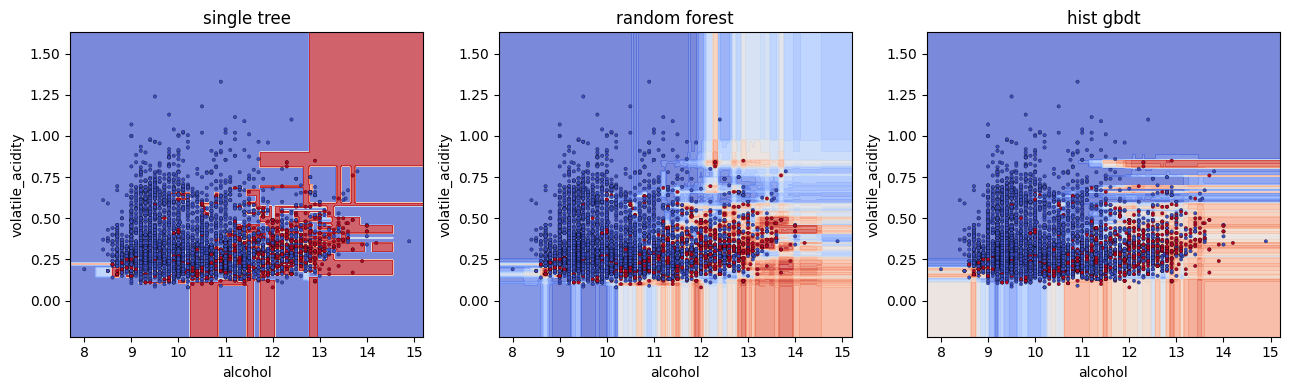

In [10]:
from sklearn.ensemble import HistGradientBoostingClassifier

def plot_regions(model, ax, X2, y2, title):
    x0 = np.linspace(X2.iloc[:, 0].min() - 0.3, X2.iloc[:, 0].max() + 0.3, 300)
    x1 = np.linspace(X2.iloc[:, 1].min() - 0.3, X2.iloc[:, 1].max() + 0.3, 300)
    xx, yy = np.meshgrid(x0, x1)
    grid = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=X2.columns)
    zz = model.predict_proba(grid)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=20, cmap='coolwarm', alpha=0.7)
    ax.scatter(X2.iloc[:, 0], X2.iloc[:, 1], c=y2, cmap='coolwarm', s=6,
               edgecolor='k', linewidths=0.2)
    ax.set_title(title); ax.set_xlabel(X2.columns[0]); ax.set_ylabel(X2.columns[1])

feats2 = ['alcohol', 'volatile_acidity']
X2 = X_tr[feats2]
trio = [('single tree', DecisionTreeClassifier(random_state=SEED)),
        ('random forest', RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=1)),
        ('hist gbdt', HistGradientBoostingClassifier(random_state=SEED))]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (nm, m) in zip(axes, trio):
    m.fit(X2, y_tr); plot_regions(m, ax, X2, y_tr, nm)
plt.tight_layout(); plt.show()

**5. Regression on the Yerevan rent toy.** A synthetic rent-vs-area set; the forest's error
falls then plateaus with more trees (same variance story, regression flavor). Extra Trees
(bonus) is a touch faster and comparable.

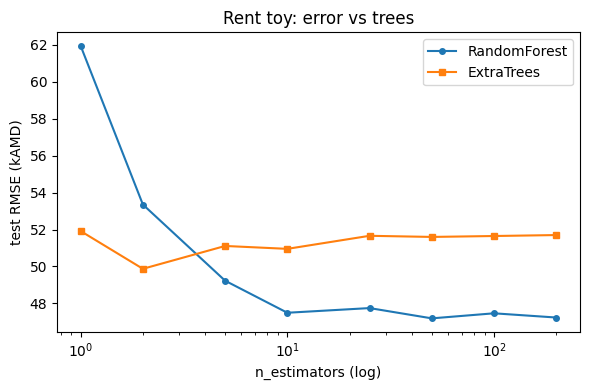

RF RMSE: 1 tree = 61.9 -> 200 trees = 47.2


In [11]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(SEED)
area = rng.uniform(30, 120, 400)                        # m^2
rent = 80 + 4.5 * area + rng.normal(0, 40, 400)         # kAMD, with noise
Ar = area.reshape(-1, 1)
Ar_tr, Ar_te, r_tr, r_te = train_test_split(Ar, rent, test_size=0.3, random_state=SEED)

ns = [1, 2, 5, 10, 25, 50, 100, 200]
rmse_rf, rmse_et = [], []
for n in ns:
    rf_r = RandomForestRegressor(n_estimators=n, random_state=SEED, n_jobs=1).fit(Ar_tr, r_tr)
    et_r = ExtraTreesRegressor(n_estimators=n, random_state=SEED, n_jobs=1).fit(Ar_tr, r_tr)
    rmse_rf.append(mean_squared_error(r_te, rf_r.predict(Ar_te)) ** 0.5)
    rmse_et.append(mean_squared_error(r_te, et_r.predict(Ar_te)) ** 0.5)
plt.figure(figsize=(6, 4))
plt.semilogx(ns, rmse_rf, '-o', ms=4, label='RandomForest')
plt.semilogx(ns, rmse_et, '-s', ms=4, label='ExtraTrees')
plt.xlabel('n_estimators (log)'); plt.ylabel('test RMSE (kAMD)'); plt.legend()
plt.title('Rent toy: error vs trees'); plt.tight_layout(); plt.show()
print('RF RMSE: 1 tree =', round(rmse_rf[0], 1), '-> 200 trees =', round(rmse_rf[-1], 1))

## HW3 - boost the tree ([19]-[20])

**1. By hand - 3 rounds of gradient boosting on a tiny rent table.** Init with the mean, fit a
depth-1 stump to the residuals, update with learning rate eta, and watch the residual MSE fall.

In [12]:
from sklearn.tree import DecisionTreeRegressor

a = np.array([40, 55, 60, 75, 90, 110], dtype=float).reshape(-1, 1)   # area
rent_toy = np.array([250, 300, 340, 390, 470, 560], dtype=float)      # kAMD
eta = 0.5

pred = np.full_like(rent_toy, rent_toy.mean())      # round 0: predict the mean
print(f"round 0: pred=mean={rent_toy.mean():.1f}   MSE={np.mean((rent_toy-pred)**2):.1f}")
for k in range(1, 4):
    resid = rent_toy - pred
    stump = DecisionTreeRegressor(max_depth=1).fit(a, resid)
    pred = pred + eta * stump.predict(a)
    print(f"round {k}: fit stump to residuals, update with eta={eta}   "
          f"MSE={np.mean((rent_toy-pred)**2):.1f}")
print("\nResiduals (and MSE) shrink each round - boosting reduces bias step by step.")

round 0: pred=mean=385.0   MSE=10891.7
round 1: fit stump to residuals, update with eta=0.5   MSE=4554.2
round 2: fit stump to residuals, update with eta=0.5   MSE=2216.1
round 3: fit stump to residuals, update with eta=0.5   MSE=1205.5

Residuals (and MSE) shrink each round - boosting reduces bias step by step.


**2. HistGradientBoosting with early stopping, onto the scoreboard.**

In [13]:
gb = record('hist gradient boosting', HistGradientBoostingClassifier(
    early_stopping=True, validation_fraction=0.1, n_iter_no_change=20,
    random_state=SEED))
print('stopped after', gb.n_iter_, 'iterations (early stopping picked it)')

hist gradient boosting acc=0.878  f1=0.639  auc=0.905
stopped after 100 iterations (early stopping picked it)


**3a. Tune `learning_rate` (early stopping picks the tree count).**

In [14]:
best = (None, 0.0)
for lr in [0.01, 0.03, 0.1, 0.3]:
    m = HistGradientBoostingClassifier(learning_rate=lr, early_stopping=True,
                                       validation_fraction=0.1, n_iter_no_change=20,
                                       random_state=SEED).fit(X_tr, y_tr)
    auc = roc_auc_score(y_te, m.predict_proba(X_te)[:, 1])
    print(f"learning_rate={lr:<5}  test AUC={auc:.3f}  ({m.n_iter_} trees)")
    if auc > best[1]:
        best = (lr, auc)
print('best learning_rate:', best[0])

learning_rate=0.01   test AUC=0.863  (100 trees)


learning_rate=0.03   test AUC=0.894  (100 trees)


learning_rate=0.1    test AUC=0.905  (100 trees)


learning_rate=0.3    test AUC=0.904  (63 trees)
best learning_rate: 0.1


**3b. LightGBM with a monotonic constraint on `alcohol`.** First check the direction (higher
alcohol correlates with 'good'), then force P(good) to be non-decreasing in alcohol. The
constraint costs at most a hair of AUC but guarantees a sensible, monotone response.

In [15]:
corr = np.corrcoef(X_tr['alcohol'], y_tr)[0, 1]
print(f"corr(alcohol, good) = {corr:+.3f}  -> constrain alcohol to be non-decreasing (+1)")

constr = [1 if f == 'alcohol' else 0 for f in feature_names]
lgb_free = LGBMClassifier(n_estimators=300, random_state=SEED, verbose=-1).fit(X_tr, y_tr)
lgb_mono = LGBMClassifier(n_estimators=300, monotone_constraints=constr,
                          random_state=SEED, verbose=-1).fit(X_tr, y_tr)
print(f"AUC  unconstrained={roc_auc_score(y_te, lgb_free.predict_proba(X_te)[:,1]):.3f}  "
      f"monotone(alcohol)={roc_auc_score(y_te, lgb_mono.predict_proba(X_te)[:,1]):.3f}")

corr(alcohol, good) = +0.379  -> constrain alcohol to be non-decreasing (+1)


AUC  unconstrained=0.922  monotone(alcohol)=0.917


**Bonus - forcing overfitting.** A high learning rate + deep trees + no early stopping: train
log-loss falls to ~0 while test log-loss turns back up. That U-turn is exactly what early
stopping catches - and it is why boosting, unlike a forest, *can* overfit with more trees.

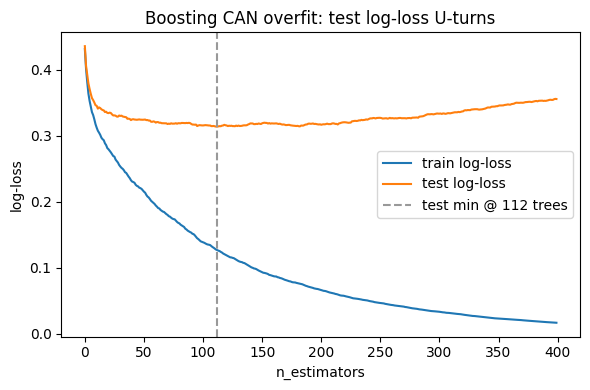

In [16]:
from sklearn.ensemble import GradientBoostingClassifier
gbo = GradientBoostingClassifier(n_estimators=400, learning_rate=0.3, max_depth=4,
                                 random_state=SEED).fit(X_tr, y_tr)
tr_ll, te_ll = [], []
for p_tr, p_te in zip(gbo.staged_predict_proba(X_tr), gbo.staged_predict_proba(X_te)):
    tr_ll.append(log_loss(y_tr, p_tr)); te_ll.append(log_loss(y_te, p_te))
plt.figure(figsize=(6, 4))
plt.plot(tr_ll, label='train log-loss')
plt.plot(te_ll, label='test log-loss')
plt.axvline(int(np.argmin(te_ll)), color='0.6', ls='--',
            label=f'test min @ {int(np.argmin(te_ll))} trees')
plt.xlabel('n_estimators'); plt.ylabel('log-loss'); plt.legend()
plt.title('Boosting CAN overfit: test log-loss U-turns'); plt.tight_layout(); plt.show()

## The running scoreboard

In [17]:
board = pd.DataFrame(scores).T.round(3)
print(board.to_string())
t, r = scores['pruned tree'], scores['random forest']
print(f"\nUnlike Titanic, the ensembles clearly beat the single tree here: "
      f"AUC {t['auc']:.2f} -> {r['auc']:.2f} and F1 {t['f1']:.2f} -> {r['f1']:.2f} "
      f"(a raw unpruned tree overfits to AUC ~0.74). Random forest and gradient boosting "
      f"land close; tuning ([20]) decides the winner.")
board

                          acc     f1    auc
pruned tree             0.838  0.531  0.836
random forest           0.887  0.661  0.922
hist gradient boosting  0.878  0.639  0.905

Unlike Titanic, the ensembles clearly beat the single tree here: AUC 0.84 -> 0.92 and F1 0.53 -> 0.66 (a raw unpruned tree overfits to AUC ~0.74). Random forest and gradient boosting land close; tuning ([20]) decides the winner.


,acc,f1,auc
pruned tree,0.838,0.531,0.836
random forest,0.887,0.661,0.922
hist gradient boosting,0.878,0.639,0.905
